In [2]:
import pandas as pd

In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from pathlib import Path
Path("outputs").mkdir(parents=True, exist_ok=True)

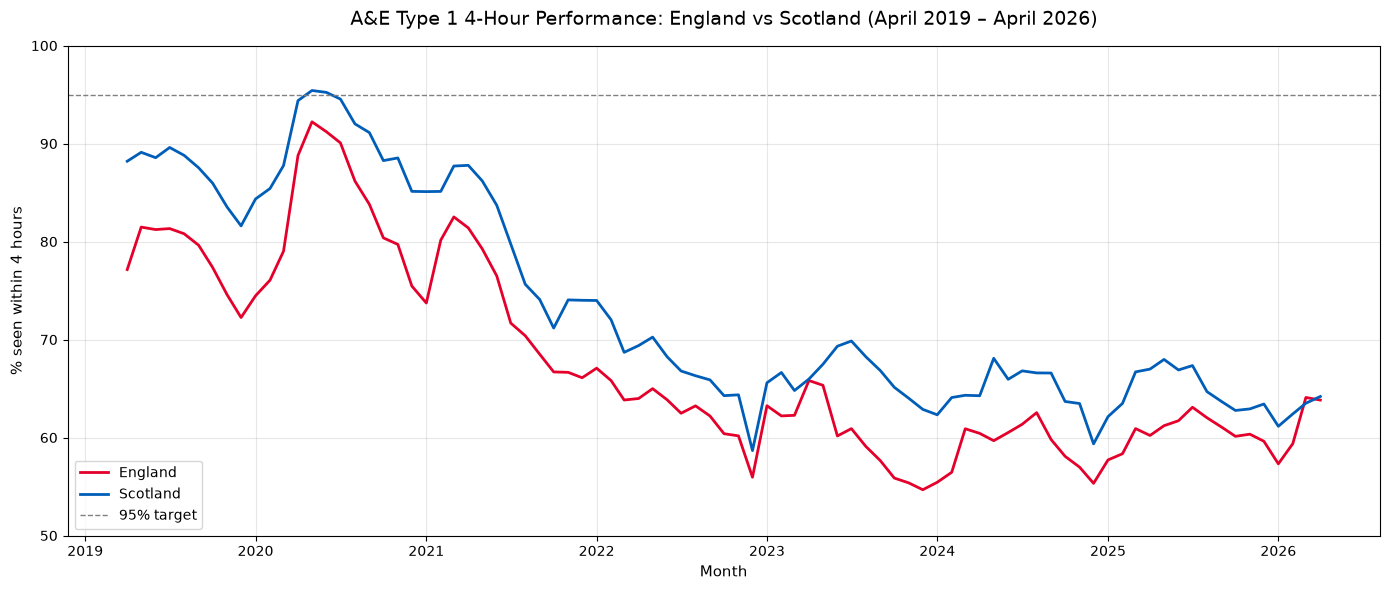

Chart saved to outputs/q1_performance_trend.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the country-level view we built in Phase 1
country_month = pd.read_csv("data/processed/country_month_view.csv", parse_dates=["period"])

# Split into two dataframes for cleaner plotting
england = country_month[country_month["country"] == "England"].sort_values("period")
scotland = country_month[country_month["country"] == "Scotland"].sort_values("period")

# Build the chart
plt.figure(figsize=(14, 6))

plt.plot(england["period"], england["pct_4hr_type1"], label="England", color="#E4002B", linewidth=2)
plt.plot(scotland["period"], scotland["pct_4hr_type1"], label="Scotland", color="#005EB8", linewidth=2)

# Add the 95% target line
plt.axhline(y=95, color="grey", linestyle="--", linewidth=1, label="95% target")

# Labels and styling
plt.title("A&E Type 1 4-Hour Performance: England vs Scotland (April 2019 – April 2026)", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=11)
plt.ylabel("% seen within 4 hours", fontsize=11)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(50, 100)

plt.tight_layout()
plt.savefig("outputs/q1_performance_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to outputs/q1_performance_trend.png")

In [6]:
import pandas as pd

# Load the country-level view
country_month = pd.read_csv("data/processed/country_month_view.csv", parse_dates=["period"])

# Function to get key stats for one country
def get_country_summary(df, country_name):
    country_df = df[df["country"] == country_name].sort_values("period").reset_index(drop=True)
    
    start = country_df.iloc[0]
    current = country_df.iloc[-1]
    peak_row = country_df.loc[country_df["pct_4hr_type1"].idxmax()]
    trough_row = country_df.loc[country_df["pct_4hr_type1"].idxmin()]
    
    return {
        "country": country_name,
        "start_month": start["period"].strftime("%b %Y"),
        "start_pct": round(start["pct_4hr_type1"], 1),
        "current_month": current["period"].strftime("%b %Y"),
        "current_pct": round(current["pct_4hr_type1"], 1),
        "peak_month": peak_row["period"].strftime("%b %Y"),
        "peak_pct": round(peak_row["pct_4hr_type1"], 1),
        "trough_month": trough_row["period"].strftime("%b %Y"),
        "trough_pct": round(trough_row["pct_4hr_type1"], 1),
        "average_pct": round(country_df["pct_4hr_type1"].mean(), 1),
        "change_pct_points": round(current["pct_4hr_type1"] - start["pct_4hr_type1"], 1),
    }

# Get summary for both countries
summary = pd.DataFrame([
    get_country_summary(country_month, "England"),
    get_country_summary(country_month, "Scotland")
])

print("Q1 — Performance Trend Summary")
print("=" * 60)
print(summary.T)  # transpose so metrics are rows, countries are columns

Q1 — Performance Trend Summary
                          0         1
country             England  Scotland
start_month        Apr 2019  Apr 2019
start_pct              77.1      88.2
current_month      Apr 2026  Apr 2026
current_pct            63.8      64.2
peak_month         May 2020  May 2020
peak_pct               92.2      95.4
trough_month       Dec 2023  Dec 2022
trough_pct             54.7      58.7
average_pct            67.6      73.4
change_pct_points     -13.3     -24.0


In [7]:
summary.to_csv("outputs/q1_summary_stats.csv", index=False)
print("Saved to outputs/q1_summary_stats.csv")

Saved to outputs/q1_summary_stats.csv



# Q1: A&E 4-Hour Performance Trend, April 2019 → April 2026

Both England and Scotland saw substantial declines in A&E 4-hour performance across the 7-year window, with the picture masked by the temporary COVID demand collapse of 2020. Both countries hit their peak in May 2020 — England at 92.2%, Scotland at 95.4%, as first-lockdown A&E attendance fell away. From that artificial high, both declined steadily through the recovery period. Scotland hit its lowest point (58.7%) in December 2022, England a year later (54.7% in December 2023), suggesting Scotland's smaller board structure reached its crisis point earlier.

By April 2026, both countries had converged around 64%, meaning Scotland's traditional lead has essentially disappeared. Scotland's overall average (73.4%) remained higher than England's (67.6%), but Scotland lost 24 percentage points across the period compared with England's 13. Neither country has come close to the 95% target since May 2020.


Q2 — Benchmarking Summary (7-year averages, per 100k of national population)
                                0         1
country                   England  Scotland
avg_attendances_per_100k   2296.0    2018.0
avg_breaches_per_100k       759.0     546.0
avg_waits_12hr_per_100k      42.9      67.5
avg_pct_4hr                  67.6      73.4


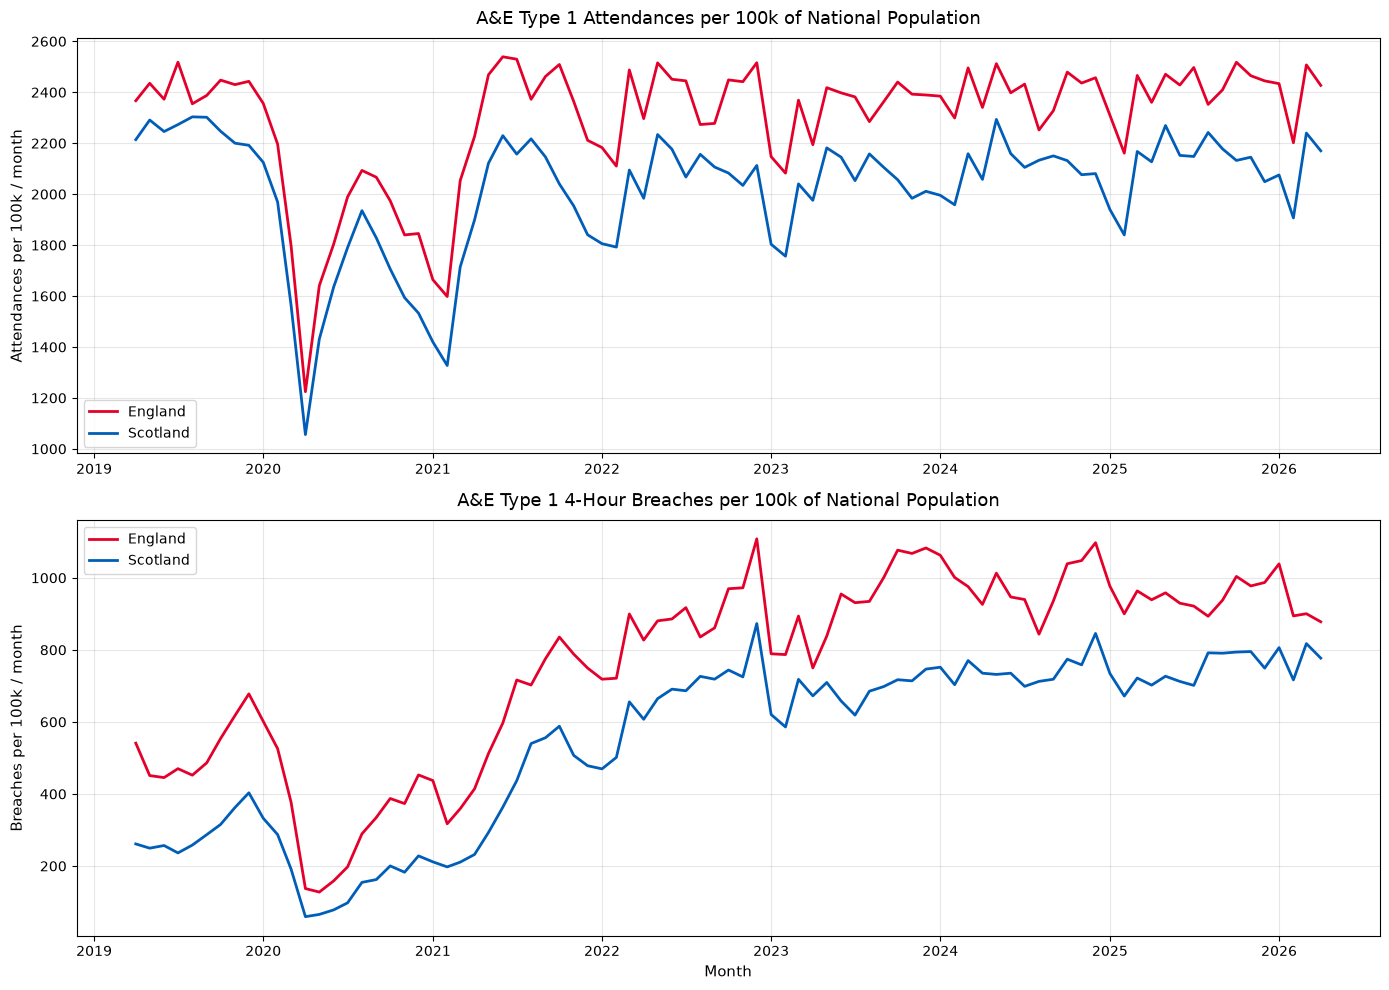


Saved chart and summary to outputs/


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Path("outputs").mkdir(parents=True, exist_ok=True)

# Load country-level view
country_month = pd.read_csv("data/processed/country_month_view.csv", parse_dates=["period"])

# ============================================
# Part 1 — the summary comparison table
# ============================================

def get_q2_summary(df, country_name):
    country_df = df[df["country"] == country_name].sort_values("period")
    return {
        "country": country_name,
        "avg_attendances_per_100k": round(country_df["attendances_per_100k"].mean(), 0),
        "avg_breaches_per_100k": round(country_df["breaches_4hr_per_100k"].mean(), 0),
        "avg_waits_12hr_per_100k": round(country_df["waits_12hr_per_100k"].mean(), 1),
        "avg_pct_4hr": round(country_df["pct_4hr_type1"].mean(), 1),
    }

q2_summary = pd.DataFrame([
    get_q2_summary(country_month, "England"),
    get_q2_summary(country_month, "Scotland"),
])

print("Q2 — Benchmarking Summary (7-year averages, per 100k of national population)")
print("=" * 75)
print(q2_summary.T)

# ============================================
# Part 2 — the trajectory chart (breaches per 100k)
# ============================================

england = country_month[country_month["country"] == "England"].sort_values("period")
scotland = country_month[country_month["country"] == "Scotland"].sort_values("period")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top — attendances per 100k
axes[0].plot(england["period"], england["attendances_per_100k"], label="England", color="#E4002B", linewidth=2)
axes[0].plot(scotland["period"], scotland["attendances_per_100k"], label="Scotland", color="#005EB8", linewidth=2)
axes[0].set_title("A&E Type 1 Attendances per 100k of National Population", fontsize=13, pad=10)
axes[0].set_ylabel("Attendances per 100k / month", fontsize=11)
axes[0].legend(loc="best", fontsize=10)
axes[0].grid(True, alpha=0.3)

# Bottom — breaches per 100k
axes[1].plot(england["period"], england["breaches_4hr_per_100k"], label="England", color="#E4002B", linewidth=2)
axes[1].plot(scotland["period"], scotland["breaches_4hr_per_100k"], label="Scotland", color="#005EB8", linewidth=2)
axes[1].set_title("A&E Type 1 4-Hour Breaches per 100k of National Population", fontsize=13, pad=10)
axes[1].set_ylabel("Breaches per 100k / month", fontsize=11)
axes[1].set_xlabel("Month", fontsize=11)
axes[1].legend(loc="best", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/q2_benchmarking_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

# Save summary
q2_summary.to_csv("outputs/q2_summary_stats.csv", index=False)
print("\nSaved chart and summary to outputs/")

In [9]:
# The four numbers from your Q2 summary
eng_att = 2296
sco_att = 2018
eng_bre = 759
sco_bre = 546
eng_12h = 42.9
sco_12h = 67.5

# Attendances — England higher, Scotland baseline
att_diff = (eng_att - sco_att) / sco_att * 100
print(f"England has {att_diff:.1f}% more attendances per 100k than Scotland")

# Breaches — England higher, Scotland baseline
bre_diff = (eng_bre - sco_bre) / sco_bre * 100
print(f"England has {bre_diff:.1f}% more breaches per 100k than Scotland")

# 12-hour waits — Scotland higher, England baseline
h12_diff = (sco_12h - eng_12h) / eng_12h * 100
print(f"Scotland has {h12_diff:.1f}% more 12-hour waits per 100k than England")

England has 13.8% more attendances per 100k than Scotland
England has 39.0% more breaches per 100k than Scotland
Scotland has 57.3% more 12-hour waits per 100k than England



# Q2: England vs Scotland Benchmarking (per 100k of national population)

When A&E metrics are normalised by population, England shows consistently higher demand and consistently more system pressure than Scotland. Over the 7-year window, England averaged 2,296 Type 1 attendances per 100k of national population per month, compared with Scotland's 2,018, roughly 14% more demand per person. Both countries' demand tracked the same COVID shocks (April 2020 collapse, early 2021 dip, mid-2021 recovery) but England's per-100k figure sat above Scotland's for every single month of the period.

On the 4-hour target, England breached 759 times per 100k on average, versus Scotland's 546, a gap of ~39%. That gap is proportionally larger than the demand gap, indicating England's system doesn't just handle more patients but handles them less efficiently per patient. Scotland's overall 4-hour compliance averaged 73.4% against England's 67.6%.

The 12-hour waits comparison shows Scotland with a higher rate (67.5 vs 42.9 per 100k), but this is a methodological artefact, not a performance gap. England reports 12-hour waits from Decision-to-Admit, capturing long waits only after an admission decision. Scotland reports from arrival, capturing all patients whose total time exceeded 12 hours. Scotland's definition catches more patients, meaning England's true 12-hour picture is likely worse than reported. This methodology gap is documented as a comparison limitation.

In [11]:
import pandas as pd
from pathlib import Path

Path("outputs").mkdir(parents=True, exist_ok=True)

# Load the trust-level file
combined = pd.read_csv("data/processed/combined_ae_with_population.csv", parse_dates=["period"])

# Aggregate to trust level — average performance across all months
trust_summary = (
    combined
    .groupby(["country", "trust_region", "trust_name"], as_index=False)
    .agg({
        "attendances_type1": "sum",       # total attendances across all months
        "breaches_4hr_type1": "sum",       # total breaches across all months
    })
)

# Recalculate weighted 4-hour % from summed counts (not average of averages)
trust_summary["pct_4hr_avg"] = (
    1 - (trust_summary["breaches_4hr_type1"] / trust_summary["attendances_type1"])
) * 100

# Show top 10 and bottom 10 for each country
for country in ["England", "Scotland"]:
    country_trusts = trust_summary[trust_summary["country"] == country].sort_values("pct_4hr_avg", ascending=False)
    
    
    print(f"{country.upper()} — TOP 10 BEST-PERFORMING TRUSTS/HOSPITALS")
    print(f"{'='*70}")
    print(country_trusts.head(10)[["trust_name", "attendances_type1", "pct_4hr_avg"]].to_string(index=False))
    
    print(f"\n{country.upper()} — TOP 10 WORST-PERFORMING TRUSTS/HOSPITALS")
    print(f"{'='*70}")
    print(country_trusts.tail(10)[["trust_name", "attendances_type1", "pct_4hr_avg"]].to_string(index=False))

ENGLAND — TOP 10 BEST-PERFORMING TRUSTS/HOSPITALS
                                                     trust_name  attendances_type1  pct_4hr_avg
   Luton And Dunstable University Hospital NHS Foundation Trust           105564.0    99.700656
                              Mid Yorkshire Hospitals NHS Trust           799030.0    99.563220
                            Poole Hospital NHS Foundation Trust            96440.0    98.574243
                                 Portsmouth Hospitals NHS Trust           142015.0    96.942576
                      Sheffield Children's NHS Foundation Trust           387516.0    92.660174
              Homerton University Hospital NHS Foundation Trust           324697.0    91.083995
                  Western Sussex Hospitals NHS Foundation Trust           271190.0    89.834065
Basildon And Thurrock University Hospitals NHS Foundation Trust           135821.0    89.359525
          Chelsea And Westminster Hospital NHS Foundation Trust          1565889.0    

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Path("outputs").mkdir(parents=True, exist_ok=True)

# Load trust-level data
combined = pd.read_csv("data/processed/combined_ae_with_population.csv", parse_dates=["period"])

# Aggregate to trust level again — total attendances and breaches across all months
trust_summary = (
    combined
    .groupby(["country", "trust_region", "trust_name"], as_index=False)
    .agg({
        "attendances_type1": "sum",
        "breaches_4hr_type1": "sum",
    })
)

trust_summary["pct_4hr_avg"] = (
    1 - (trust_summary["breaches_4hr_type1"] / trust_summary["attendances_type1"])
) * 100

# Now aggregate again — this time to region level, but keep the spread
region_stats = (
    trust_summary
    .groupby(["country", "trust_region"], as_index=False)
    .agg(
        trust_count=("trust_name", "count"),
        avg_pct=("pct_4hr_avg", "mean"),
        min_pct=("pct_4hr_avg", "min"),
        max_pct=("pct_4hr_avg", "max"),
        std_pct=("pct_4hr_avg", "std"),
    )
)

region_stats["spread"] = region_stats["max_pct"] - region_stats["min_pct"]
region_stats = region_stats.round(1)

# Show England regions
print("ENGLAND — REGIONAL VARIATION")
print("=" * 80)
england_regions = region_stats[region_stats["country"] == "England"].sort_values("avg_pct", ascending=False)
print(england_regions.to_string(index=False))

# Show Scotland boards
print(f"\nSCOTLAND — BOARD VARIATION")
print("=" * 80)
scotland_regions = region_stats[region_stats["country"] == "Scotland"].sort_values("avg_pct", ascending=False)
print(scotland_regions.to_string(index=False))

ENGLAND — REGIONAL VARIATION
country                          trust_region  trust_count  avg_pct  min_pct  max_pct  std_pct  spread
England               NHS England South East            22     71.8     59.1     96.9      9.5    37.8
England          NHS England East Of England            20     70.8     49.0     99.7     12.7    50.7
England               NHS England South West            21     70.4     53.0     98.6     11.2    45.6
England NHS England North East And Yorkshire            25     70.3     47.1     99.6     11.7    52.5
England                    NHS England London           20     68.1     48.7     91.1     12.5    42.4
England                 NHS England Midlands            24     65.1     47.7     82.2      9.8    34.5
England               NHS England North West            27     63.7     49.0     83.1      8.5    34.0

SCOTLAND — BOARD VARIATION
 country                trust_region  trust_count  avg_pct  min_pct  max_pct  std_pct  spread
Scotland           NHS We

England: correlation between attendances and 4-hour % = -0.221
Scotland: correlation between attendances and 4-hour % = -0.707


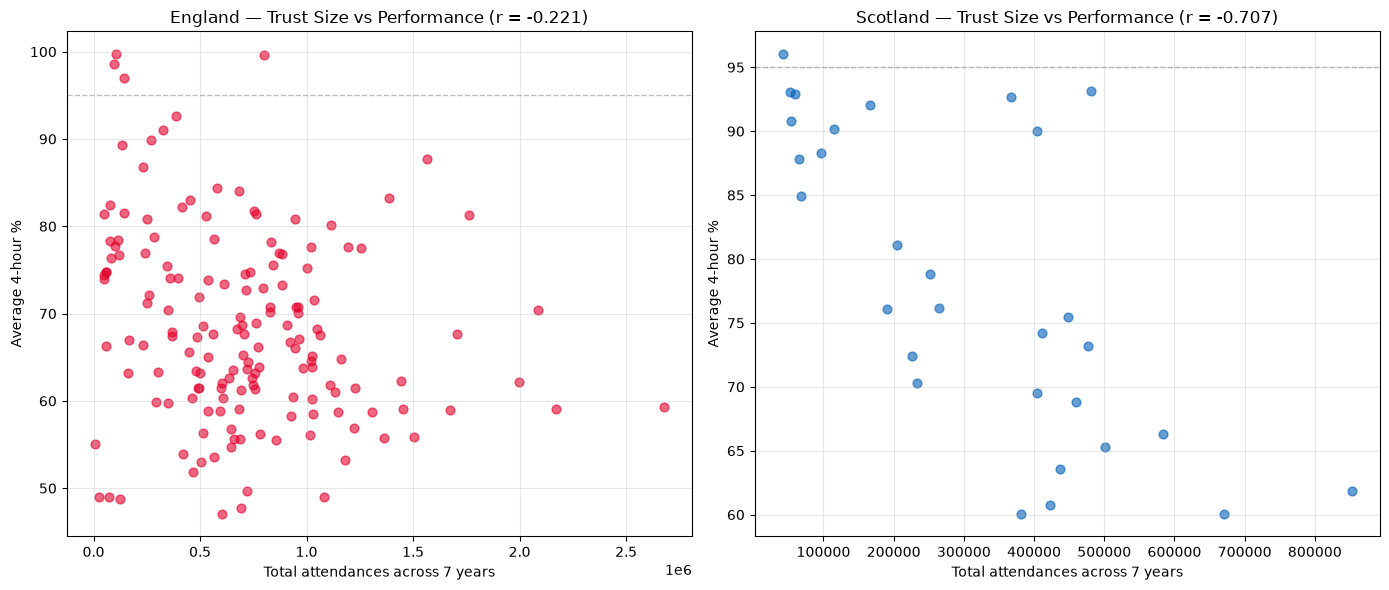

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Path("outputs").mkdir(parents=True, exist_ok=True)

# Load trust-level data
combined = pd.read_csv("data/processed/combined_ae_with_population.csv", parse_dates=["period"])

# Aggregate to trust level
trust_summary = (
    combined
    .groupby(["country", "trust_region", "trust_name"], as_index=False)
    .agg({
        "attendances_type1": "sum",
        "breaches_4hr_type1": "sum",
    })
)
trust_summary["pct_4hr_avg"] = (
    1 - (trust_summary["breaches_4hr_type1"] / trust_summary["attendances_type1"])
) * 100

# ============================================
# Correlation calculation — per country
# ============================================

for country in ["England", "Scotland"]:
    country_df = trust_summary[trust_summary["country"] == country]
    r = country_df["attendances_type1"].corr(country_df["pct_4hr_avg"])
    print(f"{country}: correlation between attendances and 4-hour % = {r:.3f}")

# ============================================
# Scatter plot — one panel per country
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, country, colour in zip(axes, ["England", "Scotland"], ["#E4002B", "#005EB8"]):
    country_df = trust_summary[trust_summary["country"] == country]
    r = country_df["attendances_type1"].corr(country_df["pct_4hr_avg"])
    
    ax.scatter(country_df["attendances_type1"], country_df["pct_4hr_avg"], 
                alpha=0.6, color=colour, s=40)
    ax.axhline(y=95, color="grey", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(f"{country} — Trust Size vs Performance (r = {r:.3f})", fontsize=12)
    ax.set_xlabel("Total attendances across 7 years", fontsize=10)
    ax.set_ylabel("Average 4-hour %", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/q3_size_vs_performance.png", dpi=150, bbox_inches="tight")
plt.show()


# Q3: Driver Analysis: What Explains the Differences?

## The headline finding
National averages hide enormous variation. In England, individual trust performance ranges from below 50% to nearly 100% across the 7-year window a 50+ percentage point spread. In Scotland, the range is narrower but still substantial, from 60% to 96%. Any policy response based only on national averages would miss where the pressure actually lives.

## What size does and doesn't explain
England shows essentially no relationship between trust size and performance (correlation = -0.22). Very large English trusts appear at both extremes: Chelsea & Westminster (1.5M attendances) averages 88%, while Barking Havering (similar size) averages under 50%. Size doesn't drive English performance trust-level factors like leadership, staffing, and patient flow do.

Scotland shows a much stronger negative correlation (-0.71) bigger hospitals almost always perform worse. But size in Scotland is a proxy for urban vs rural context. Small hospitals in Western Isles, Orkney and Shetland face low, predictable demand and hit target. Big city A&Es in Edinburgh, Glasgow and Aberdeen face the pressure of urban emergency care. The underlying driver is geography, with size as its visible marker.

## What regions do and don't explain
England's regional averages differ by only ~8 percentage points from best to worst, but every region contains trusts at both extremes. The East of England has one trust averaging 99.7% and another at 49%. Regions aren't the driver; they mask trust-level variation rather than reveal it.

Scotland's board averages differ by ~35 percentage points, but this is driven by the urban-rural split small boards are internally consistent, while the three biggest urban boards (Lothian, Grampian, Greater Glasgow & Clyde) contain both a struggling major city hospital and better-performing smaller sites within them.

## What we cannot answer from this data
This dataset doesn't include staffing levels, bed occupancy, ambulance handover times, GP access, or deprivation indicators. Any of those could be the real driver behind the trust-level variation this analysis exposes. What the data allows me to say is where the story is trust-level in England, urban-rural in Scotland — and where a fuller driver analysis would need to look next.

## One outlier worth flagging
Luton & Dunstable at 99.7% over 7 years is remarkable in a national context averaging 67.6%. That could be a genuinely exceptional service or a data anomaly a merger, reclassification, or reporting change. Extreme outliers deserve investigation before being used to argue anything.
